# Getting started with ORCHARD

`ORCHARD` is a 1-D planetary evolution code. It takes a planet's mass and composition, solves for its interior structure, and marches that structure forward in time for gigayears. You get the radius, luminosity, and temperature profile along the way, and, if you ask for them, helium rain, metal rain, and compositional mixing.

This tutorial is the starting point. We will verify your installation, run your first model, decode what the code prints while it runs, load and plot the output, and point you at the right tutorial for wherever you want to go next. No physics decisions are required yet.

**NOTE**: The cells in this notebook assume you've already created the conda environment and downloaded the EOS tables (the two setup steps in the README). If you haven't, do that first. The verification cell below will tell you whether it worked.

## Verify the installation

Two things must be true before anything will run. First, the `orchard_env` conda environment is active, so you have the pinned NumPy/SciPy/h5py versions we test against. Second, the EOS tables are actually on disk, not just the empty `eos/` folder from a fresh clone, and not Git LFS pointer stubs. The cell below checks all of it and tells you what's missing:

In [1]:
import sys, os

print(f"Python: {sys.version.split()[0]}")

ok = True
for mod in ("numpy", "scipy", "h5py", "matplotlib", "astropy", "tqdm"):
    try:
        __import__(mod)
        print(f"  {mod:<12} OK")
    except ImportError:
        print(f"  {mod:<12} MISSING -- activate orchard_env (see README)")
        ok = False

# The same sentinel file setup_eos.py uses: present and >1 MB means real
# tables, not an LFS pointer stub.
sentinel = os.path.join("eos", "cd", "cd_aqua_pt.npz")
if os.path.exists(sentinel) and os.path.getsize(sentinel) > 1e6:
    print("  EOS tables   OK")
elif os.path.exists(sentinel):
    print("  EOS tables   STUB -- you have LFS pointers, not data. "
          "Run: python setup_eos.py")
    ok = False
else:
    print("  EOS tables   MISSING -- run: python setup_eos.py")
    ok = False

print("\nAll good -- carry on!" if ok else
      "\nFix the items above before continuing.")

Python: 3.13.13
  numpy        OK
  scipy        OK
  h5py         OK
  matplotlib   OK
  astropy      OK
  tqdm         OK
  EOS tables   OK

All good -- carry on!


## Your first model

The generic starter config is a 1 M$_J$, hot-start ($S = 10$ k$_B$/baryon), homogeneous Jupiter: [`parameter_examples/parameter_user.ini`](../parameter_examples/parameter_user.ini). Run it from a terminal at the repository root rather than from this notebook, since you'll want to watch it and your notebook kernel would be blocked for the duration:

```bash
conda activate orchard_env
python evolution.py --config parameter_examples/parameter_user.ini
```

Expect a few minutes of `Loading EOS ...` silence first (the mixture tables are large, and they load once), then a stream of timesteps. The full 10 Gyr of evolution takes roughly 10 to 20 minutes on a laptop.

### Reading the console output

While it runs you'll see three kinds of lines.

`Timestep: ... Myr, Age: ... Gyr` appears once per accepted step. The timestep starts tiny (years!) and grows adaptively as the planet's evolution slows down.

A periodic readout reports the current state, including `Radius [R_Jup]`, `T_eff [K]`, the luminosity, the surface $Y$ and $Z$, and the central pressure. This is a quick health check. For this model the radius should shrink monotonically and T$_{\rm eff}$ should fall.

`Rejecting [...] timestep, new timestep is = ...` shows up in red, especially at early ages. This is no cause for alarm. `ORCHARD` is designed to halve the timestep and retry whenever a step changes the state faster than the error tolerance allows, so frequent rejections at $t \lesssim 0.01$ Gyr just mean the adaptive timestepper is working as intended.

**Tip for first-time users:** to watch a run from another terminal, `tail -f` the log file it announces at startup, and keep an eye on the Age column, which acts as a progress bar.

### Where the output goes

Each run writes to `models/<config-name>/`, here `models/parameter_user/`. With the default `save_hdf5 = True` you get a single `evolution.h5` containing every saved snapshot. Text-mode output (one file per timestep) is available by setting `save_hdf5 = False`. Plots you generate land in `plots/`.

## Anatomy of a config file

`ORCHARD` reads every parameter's default from `parameters_default.ini` at the repository root, then applies your `--config` file on top. A user config only lists what differs from the defaults, which is why `parameter_user.ini` is about 100 lines while `parameters_default.ini` is over a thousand. The handful you'll touch first:

| Parameter | Section | What it does |
|---|---|---|
| `M_MJup` / `M_factor` | `[initial]` | Planet mass (Jupiter masses / Earth masses) |
| `S_ini` | `[initial]` | Initial entropy [k$_B$/baryon], the "hot start" knob |
| `Y_ini`, `Z_ini` | `[initial]` | Helium and metal mass fractions |
| `bc_atm` | `[boundary_condition]` | Atmosphere model (`c23` for Jupiter/Saturn, `c26` for isolated super-Jupiters, `f07` for sub-Neptunes, ...) |
| `final_age` | `[general]` | When to stop [Gyr] |
| `N` | `[general]` | Number of mass zones (resolution vs. speed) |
| `mass_core`, `mass_core_fe` | `[core]` | Compact core and iron sub-core masses [M$_\oplus$] |

Every parameter is documented in [`parameter_descriptions.md`](../parameter_descriptions.md). Keep it open in a tab. It's the single most useful reference file in the repository.

## Loading and plotting the results

Once the run finishes (or even while it's still going, since the HDF5 output supports live reading), load it with `load_models`:

Reading files...
Finished reading files...


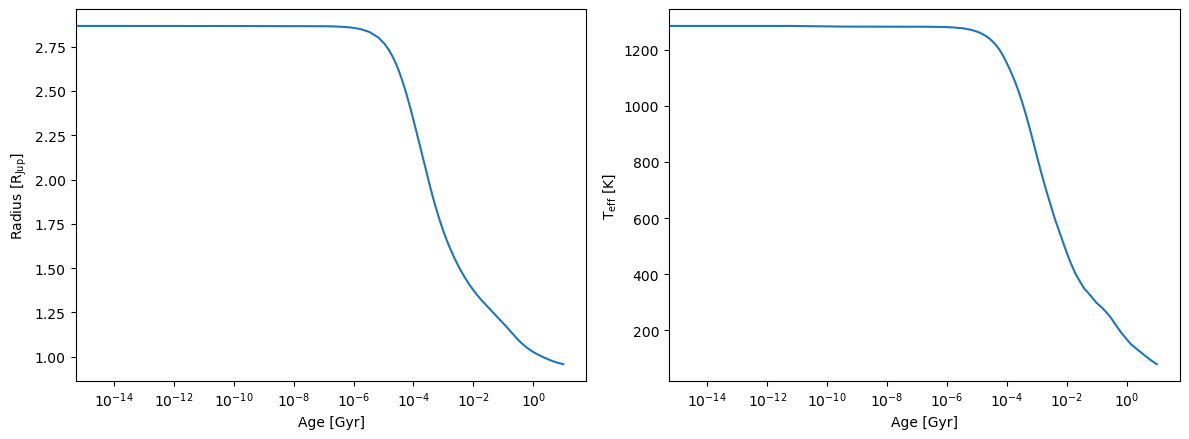

In [2]:
import load_models
from utils import const
import matplotlib.pyplot as plt

paths = ['parameter_examples/parameter_user.ini']
models = load_models.load(paths)

age_gyr = models.data_age[0] * const.s_to_Gyr
rad_rjup = models.data_rad[0] / const.rjup
teff = models.data_teff[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(age_gyr, rad_rjup)
ax1.set_xscale('log')
ax1.set_xlabel('Age [Gyr]'); ax1.set_ylabel(r'Radius [R$_{\rm Jup}$]')

ax2.plot(age_gyr, teff)
ax2.set_xscale('log')
ax2.set_xlabel('Age [Gyr]'); ax2.set_ylabel(r'T$_{\rm eff}$ [K]')

plt.tight_layout()
plt.show()

These two panels show the thermal evolution of a gas giant. A hot-start planet begins puffy and luminous, contracts rapidly while it's young, and then the contraction and cooling both slow as the interior degenerates. Most of the action is over in the first gigayear, which is why the x-axes are logarithmic.

For interior profiles (temperature, density, entropy, and composition versus depth) use the bundled `plot_class`, which builds a multi-panel summary figure from any saved age. Here $-1$ means the final timestep:

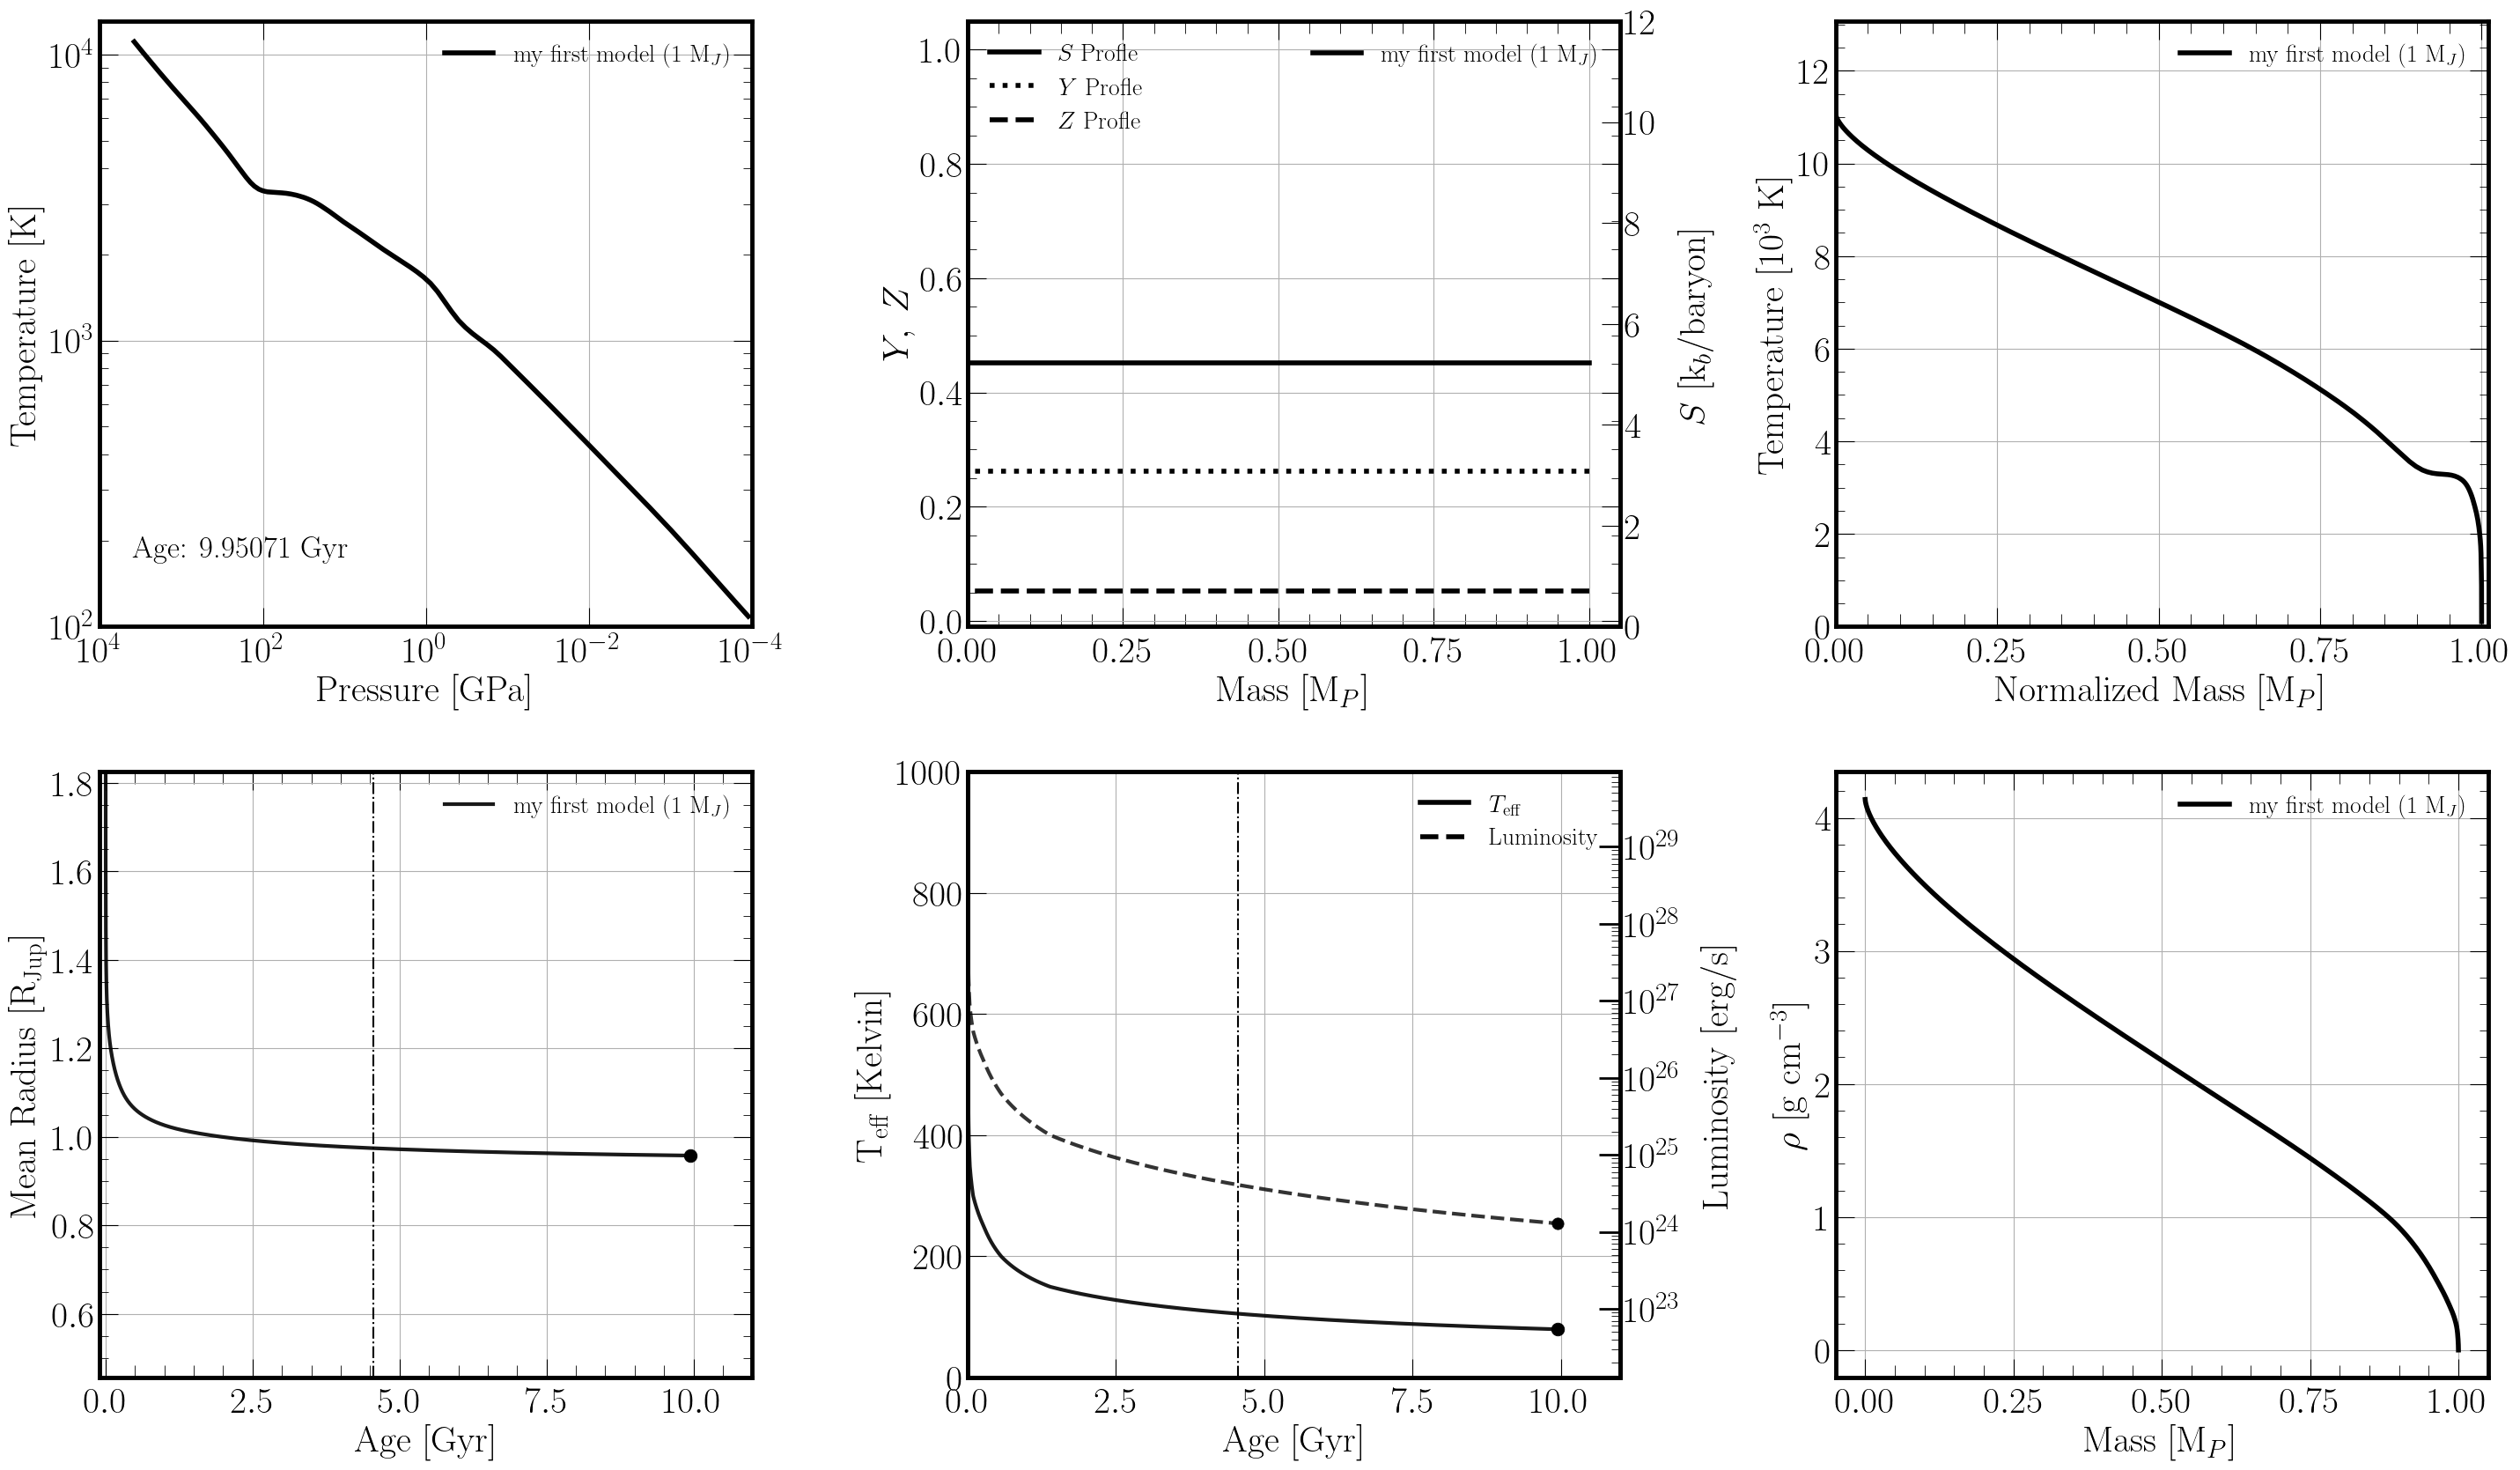

In [3]:
import plot_class

init = plot_class.init_plot(paths = paths)

init.still_plot(-1,               # age in Gyr; -1 for the final timestep
                'first_model',
                labels=[r'my first model (1 M$_J$)'],
                leg_size=20,
                panel_num=6,
        )

**NOTE**: These plotting tools are provided for convenience, diagnostics, and debugging. They are not meant to be publication quality. For custom figures, pull the arrays out of `load_models` and build your own; `tutorial_model_plotting.ipynb` shows both workflows in detail, including the panel-by-panel legend for the figure above.

## Where to go next

| I want to... | Go to |
|---|---|
| Model Jupiter, Saturn, or Uranus properly | `tutorial_solarsystem_planets.ipynb` |
| Model massive exoplanets | `tutorial_superjupiters.ipynb` |
| Model sub-Neptunes and rocky super-Earths | `tutorial_subneptunes_superearths.ipynb` |
| Set up stable regions / composition gradients | `tutorial_inhomogeneous_evolution.ipynb` |
| Build a structure now, without evolving it | `tutorial_static_structures.ipynb` |
| Compute gravity harmonics ($J_2$, $J_4$, ...) | set `rotation = True`, `tof_calc = True` (see `parameter_descriptions.md`) |
| Understand or swap the equations of state | `tutorial_eos.ipynb` |
| Get better at loading and plotting output | `tutorial_model_plotting.ipynb` |

## Getting help

Start with [`FAQ.md`](../FAQ.md) and [`parameter_descriptions.md`](../parameter_descriptions.md). If you're stuck, open a GitHub issue. A documentation assistant watches the issue tracker and will often answer usage questions within minutes and point you to the exact parameter docs or tutorial section you need. A human maintainer follows up when it can't.

## Exercises

1. **The hot-start knob.** Copy `parameter_user.ini` to a new file, set `S_ini = 8.0`, run it, and overplot the two radius-vs-age curves with `load_models`. How long does it take the two models to forget their initial conditions and converge? This convergence is why hot-vs-cold start matters for young, directly imaged planets and barely at all for Gyr-old ones.
2. **Mass matters.** Set `M_MJup = 2.0` and rerun. At 5 Gyr, is the 2 M$_J$ planet bigger or smaller than the 1 M$_J$ one? If the answer surprises you, `tutorial_superjupiters.ipynb` explains it.
3. **Break it on purpose.** Set `final_age = 0.001` and rerun. You get a single early snapshot, which is a cheap way to inspect initial conditions. Then try `N = 200` and watch it run faster (and rougher). Getting a feel for the speed/resolution trade will save you hours later.